In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

Load Data_set

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Shape:", df.shape)


Shape: (7043, 21)


In [ ]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

EDA

In [ ]:
print("\n---info---")
print(df.info())


---info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

In [ ]:
print("\n---Missing_values---")
print(df.isna().sum())


---Missing_values---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
print("\n---Duplicates---")
print(df.duplicated().sum())


---Duplicates---
0


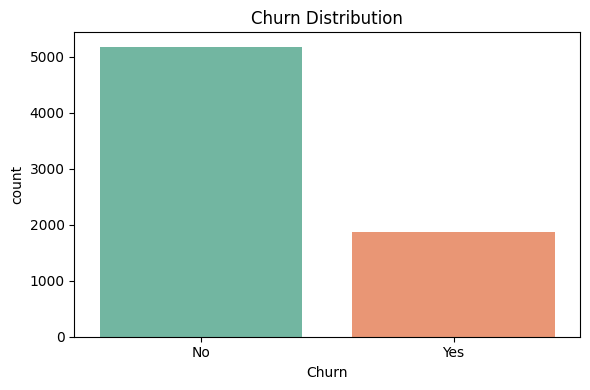

In [ ]:
# Churn Prediction
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.tight_layout()
plt.show()

Data Cleaning

In [ ]:
# fix total_charges before spliting
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Encode Target
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])

print("NaN in Churn:", df['Churn'].isnull().sum())


NaN in Churn: 0


In [ ]:
# drop redudant column
col_to_drop = [
    "customerID", "Partner", "Dependents", "PhoneService",
    "MultipleLines",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "PaperlessBilling"
]
existing_cols = [c for c in col_to_drop if c in df.columns]
df.drop(existing_cols, axis=1, inplace=True)

print("\nRemaining columns:", df.columns.tolist())


Remaining columns: ['gender', 'SeniorCitizen', 'tenure', 'InternetService', 'OnlineSecurity', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
df = df.replace(" ", np.nan)
df = df.apply(pd.to_numeric, errors="ignore")

Feature and Target Split

In [ ]:
target = "Churn"
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
num_col = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
cat_col = ["gender", "Contract","InternetService","OnlineSecurity","PaymentMethod"]

TRAIN TEST SPLIT

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

 PREPROCESSING PIPELINE (fixed order: imputer → scaler)


In [ ]:
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [ ]:
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
preprocessing = ColumnTransformer(transformers=[
    ("num", num_transformer, num_col),
    ("cat", cat_transformer, cat_col)
])

 DEFINE ALL MODELS

In [ ]:
models = {
    "logistic_regressiom": LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced'),
    "decision_tree": DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced'),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
     "SVM": SVC(probability=True, random_state=42,class_weight='balanced')
}



TRAIN, EVALUATE & COMPARE ALL MODELS

In [ ]:
results = {}
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")

    # Build pipeline
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessing),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    cv_score = cross_val_score(pipe, X, y, cv=5, scoring='accuracy').mean()

    results[name] = {
        "Accuracy": round(acc, 4),
        "ROC-AUC": round(roc_auc, 4),
        "CV Score": round(cv_score, 4),
        "y_pred": y_pred,
        "pipeline": pipe,
        "y_prob": y_prob

    }


  Model: logistic_regressiom

  Model: decision_tree

  Model: random_forest

  Model: gradient_boosting

  Model: SVM


In [ ]:
print("\nAll Model Results:\n")

for name, metrics in results.items():
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'-'*40}")

    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"ROC-AUC  : {metrics['ROC-AUC']:.4f}")
    print(f"CV Score : {metrics['CV Score']:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, metrics["y_pred"])
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, metrics["y_pred"]))


All Model Results:


Model: logistic_regressiom
----------------------------------------
Accuracy : 0.7402
ROC-AUC  : 0.8381
CV Score : 0.7382

Confusion Matrix:
[[739 296]
 [ 70 304]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.75      1409


Model: decision_tree
----------------------------------------
Accuracy : 0.7360
ROC-AUC  : 0.6574
CV Score : 0.7236

Confusion Matrix:
[[853 182]
 [190 184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted

COMPARISON TABLE

In [ ]:
print("\n\n===== MODEL COMPARISON =====")
comparison_df = pd.DataFrame({
    name: {
        "Accuracy": r["Accuracy"],
        "ROC-AUC":  r["ROC-AUC"],
        "CV Score": r["CV Score"]
    }
    for name, r in results.items()
}).T.sort_values("Accuracy", ascending=False)

print(comparison_df)



===== MODEL COMPARISON =====
                     Accuracy  ROC-AUC  CV Score
gradient_boosting      0.7928   0.8440    0.7981
random_forest          0.7693   0.8003    0.7724
SVM                    0.7459   0.8151    0.7474
logistic_regressiom    0.7402   0.8381    0.7382
decision_tree          0.7360   0.6574    0.7236


 VISUALIZATIONS

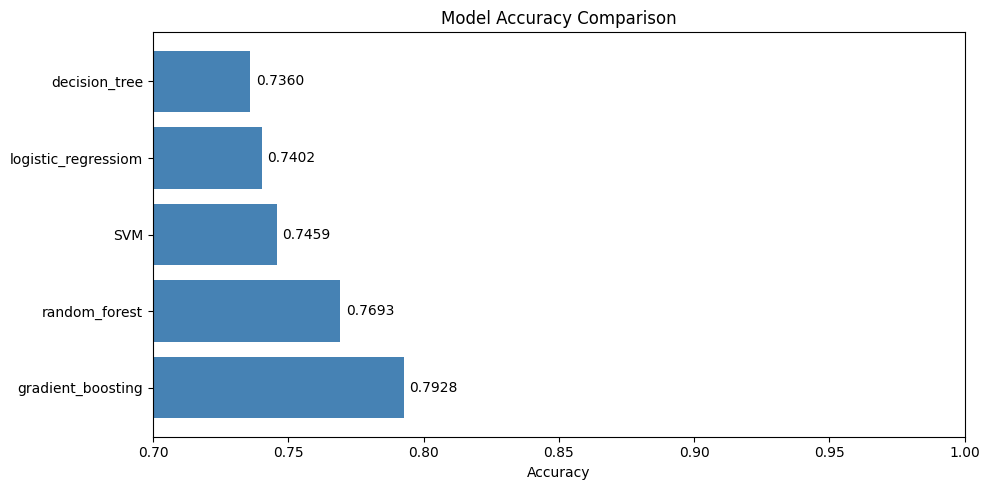

In [ ]:

# --- 10a. Accuracy Bar Chart ---
plt.figure(figsize=(10, 5))
names = list(comparison_df.index)
accs  = comparison_df["Accuracy"].values
bars  = plt.barh(names, accs, color='steelblue')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0.70, 1.0)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center')
plt.tight_layout()
plt.show()



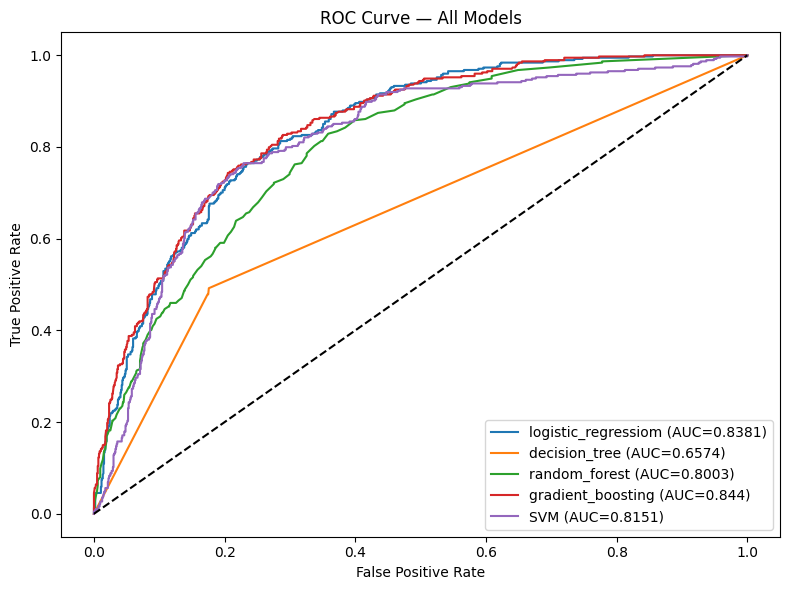

In [ ]:
# --- ROC Curves (all models) ---
plt.figure(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

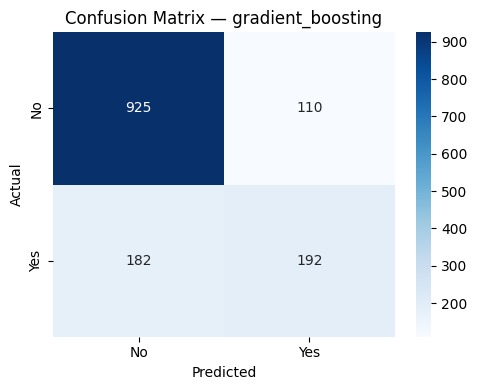

In [ ]:
# --- 10c. Confusion Matrix for Best Model ---
best_name = comparison_df.index[0]
best_pred = results[best_name]["y_pred"]
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

 BEST MODEL SUMMARY

In [ ]:
print(f"\n🏆 Best Model : {best_name}")
print(f"   Accuracy   : {results[best_name]['Accuracy']}")
print(f"   ROC-AUC    : {results[best_name]['ROC-AUC']}")
print(f"   CV Score   : {results[best_name]['CV Score']}")


🏆 Best Model : gradient_boosting
   Accuracy   : 0.7928
   ROC-AUC    : 0.844
   CV Score   : 0.7981


Deployment

In [ ]:
import joblib
joblib.dump(results[best_name]["pipeline"], "churn_model.pkl")

['churn_model.pkl']